/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_3877/913541199.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


          domain  Cluster
0    i.imgur.com        1
1      imgur.com        2
2    i.imgur.com        1
3    i.imgur.com        1
4    i.imgur.com        1
5      imgur.com        2
6  quickmeme.com        4
7       ktla.com        0
8  quickmeme.com        4
9    youtube.com        0

Cluster 0: youtubecom, latimescom, laistcom, latimesblogslatimescom, blogslaweeklycom, flickrcom, thesourcemetronet, scprorg, qkmeme, losangelescbslocalcom

Cluster 1: iimgurcom, zevlacountygov, gifsoupcom, huffingtonpostcom, homeboyindustriesorg, hollywoodreportercom, hollywoodorg, hiddenlacom, glamfminuscom, gizmodocom

Cluster 2: imgurcom, gifsoupcom, iimgurcom, huffingtonpostcom, homeboyindustriesorg, hollywoodreportercom, hollywoodorg, hiddenlacom, glamfminuscom, gizmodocom

Cluster 3: selflosangeles, deadlinecom, huffingtonpostcom, homeboyindustriesorg, hollywoodreportercom, hollywoodorg, hiddenlacom, glamfminuscom, gizmodocom, gifsoupcom

Cluster 4: quickmemecom, imageshackus, iimgurcom, huffingto

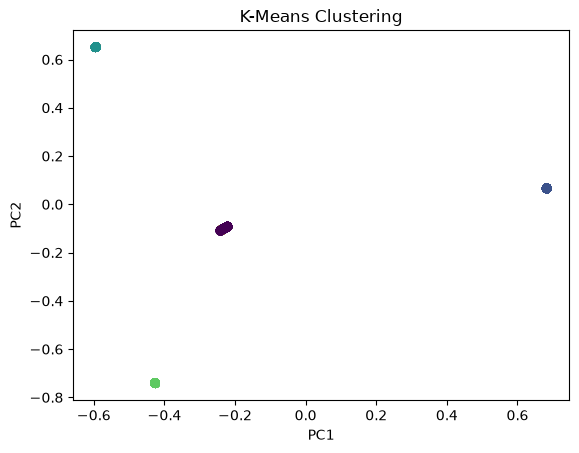

In [1]:
# NLP + K-Means Clustering

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("LosAngeles.csv")

# Select text column (change if needed)
text_col = df.select_dtypes(include="object").columns[0]
df[text_col] = df[text_col].fillna("")

# Clean text
def clean(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    return text

df["clean_text"] = df[text_col].apply(clean)

# NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# Show results
print(df[[text_col, "Cluster"]].head(10))

# Top words in each cluster
words = tfidf.get_feature_names_out()
for i in range(k):
    top = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:", ", ".join(words[j] for j in top))

# Visualisation
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X.toarray())

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df["Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering")
plt.show()

# Save results
df.to_csv("LosAngeles_clustered.csv", index=False)